# 3D Segmentation with nnU-Net and the Datamint Trainer API

This notebook trains a volumetric segmentation model on the **Synapse Multi-Organ CT** dataset using Datamint's `NNUNetTrainer`.

## What is nnU-Net?

> Isensee, F., Jaeger, P. F., Kohl, S. A. A., Petersen, J., & Maier-Hein, K. H. (2021).
> nnU-Net: A self-configuring method for deep learning-based biomedical image segmentation.
> *Nature Methods*, 18(2), 203–211.

nnU-Net is a **self-configuring** segmentation framework — you don't design a network architecture or tune hyperparameters. Instead, nnU-Net analyses your dataset and automatically decides:

- **Architecture** — 2D U-Net, 3D U-Net full-resolution, or 3D cascade (two-stage for very large volumes)
- **Patch size and batch size** — derived from GPU memory target and the median image spacing
- **Preprocessing** — target spacing, intensity normalisation strategy (CT clipping, MRI z-score, etc.)
- **Data augmentation** — rotation, scaling, elastic deformations, mirroring, based on dataset characteristics

This self-configuration happens in two offline phases (**fingerprinting** and **planning**) before any training starts, and the result is saved to `nnUNetPlans.json`. See Section 4 for a full breakdown of each pipeline step.

## What You'll Learn

1. Download and convert the Synapse Multi-Organ CT dataset to NIfTI
2. Upload 3D volumes and segmentation masks to a Datamint project
3. Train a `NNUNetTrainer` — the entire pipeline (export → fingerprint → preprocess → train → predict → import) runs in a single `trainer.fit()` call
4. Inspect MLflow-tracked metrics and visualise predictions on axial slices

## Required Dependencies

```bash
pip install datamint nibabel h5py "nnunetv2>=2.4,<3.0"
```

## ⚠️ Dataset Access

The Synapse dataset is hosted on Kaggle: https://www.kaggle.com/datasets/dogcdt/synapse

In [1]:
%pip install -q datamint gdown nibabel h5py "nnunetv2>=2.4,<3.0"

Note: you may need to restart the kernel to use updated packages.


In [5]:
from datamint import Api

PROJECT_NAME = "NNUNET__TEST_Synapse_Tutorial"
api = Api()

## 1. Setup: Create Project

In [2]:
proj = api.projects.create(
    name=PROJECT_NAME,
    description="Testing nnunet on Synapse Multi-Organ CT",
    exists_ok=True,
)
proj

NNUNET__TEST_Synapse_Tutorial
2026-06-08T13:03:02.401Z
luandalmazo@gmail.com
False
12
Testing nnunet on Synapse Multi-Organ CT


## 2. Dataset Preparation: Download Synapse

**Label map** (8 abdominal organs):

| Value | Organ |
|---|---|
| 1 | Aorta |
| 2 | Gallbladder |
| 3 | Spleen |
| 4 | Left Kidney |
| 5 | Right Kidney |
| 6 | Liver |
| 7 | Stomach |
| 8 | Pancreas |


> Download the dataset from Kaggle:

In [5]:
!curl -L -o /tmp/synapse.zip https://www.kaggle.com/api/v1/datasets/download/dogcdt/synapse

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  607M  100  607M    0     0  24.4M      0  0:00:24  0:00:24 --:--:-- 26.2M


Unzip the dataset:

In [ ]:
!unzip /tmp/synapse.zip -d /tmp/

In [7]:
from pathlib import Path

DATA_DIR = Path("/tmp/Synapse")
H5_DIR   = DATA_DIR / "test_vol_h5"

h5_files = sorted(H5_DIR.glob("*.npy.gz")) or sorted(H5_DIR.glob("*.h5"))
print(f"Found {len(h5_files)} volume files")

Found 12 volume files


### 2.1 Convert to NIfTI

Datamint accepts NIfTI (`.nii.gz`) for 3D volumes. We load each H5 file, extract the image and label arrays, and save them as NIfTI with `nibabel`.

The HDF5 files contain:
- `'image'` — float array `(H, W, D)` with HU values clipped to `[-125, 275]` and normalised to `[0, 1]`
- `'label'` — int array `(H, W, D)` with organ label values 0–8

In [8]:
import h5py
import numpy as np
import nibabel as nib

NII_DIR   = DATA_DIR / 'nifti' / 'images'
LABEL_DIR = DATA_DIR / 'nifti' / 'labels'
NII_DIR.mkdir(parents=True, exist_ok=True)
LABEL_DIR.mkdir(parents=True, exist_ok=True)

nii_image_paths = []
nii_label_paths = []

for h5_path in h5_files:
    case_id = h5_path.stem.split('.')[0]  # 'case0001.h5' -> 'case0001'

    with h5py.File(h5_path, 'r') as f:
        image = f['image'][:]   # (H, W, D) float
        label = f['label'][:]   # (H, W, D) int

    # Downsample 512x512 -> 256x256 in-plane (test purposes)
    # Reduces sliding-window patch count by ~4x during validation.
    image = image[::2, ::2, :]  # nearest-neighbour for images (float)
    label = label[::2, ::2, :]  # nearest-neighbour for labels (int), preserves class ids

    img_nii = nib.Nifti1Image(image.astype(np.float32), affine=np.eye(4))
    lbl_nii = nib.Nifti1Image(label.astype(np.uint8),   affine=np.eye(4))

    img_path = NII_DIR   / f'{case_id}.nii.gz'
    lbl_path = LABEL_DIR / f'{case_id}_label.nii.gz'

    nib.save(img_nii, img_path)
    nib.save(lbl_nii, lbl_path)

    nii_image_paths.append(img_path)
    nii_label_paths.append(lbl_path)

print(f'Converted {len(nii_image_paths)} volumes, spatial size: {image.shape}')


Converted 12 volumes, spatial size: (50, 256, 512)


## 3. Upload to Datamint

### 3.1 Upload CT Volumes

In [9]:
uploaded = api.resources.upload_resources(
    [str(p) for p in nii_image_paths],
    tags=['synapse', 'ct', 'abdomen'],
    publish_to=proj,
    progress_bar=True,
)
print(f"Uploaded {len(uploaded)} volumes")

Uploading resources: 100%|██████████| 12/12 [00:13<00:00,  1.17s/file, file=case0036.nii.gz]


Uploaded 12 volumes


### 3.2 Upload Segmentation Masks

Each label file contains integer values 0–8 (0 = background). `upload_volume_segmentation` maps each integer to its organ name.

In [10]:
from tqdm.auto import tqdm

SYNAPSE_CLASSES = {
    1: 'aorta',
    2: 'gallbladder',
    3: 'spleen',
    4: 'left_kidney',
    5: 'right_kidney',
    6: 'liver',
    7: 'stomach',
    8: 'pancreas',
}

all_resources = list(api.resources.get_list(project_name=PROJECT_NAME))
# r.filename is 'case0001.nii.gz'; strip the full extension to get 'case0001'
stem_to_resource = {r.filename.replace('.nii.gz', ''): r for r in all_resources}

for img_path, lbl_path in tqdm(zip(nii_image_paths, nii_label_paths), total=len(nii_image_paths)):
    case_id  = img_path.name.replace('.nii.gz', '')  # Path.stem gives 'case0001.nii', use .name instead
    resource = stem_to_resource[case_id]
    api.annotations.upload_volume_segmentation(
        resource=resource,
        file_path=str(lbl_path),
        name=SYNAPSE_CLASSES,
        imported_from='Synapse Multi-Organ CT',
    )

print('Segmentation masks uploaded!')


100%|██████████| 12/12 [01:07<00:00,  5.63s/it]

Segmentation masks uploaded!


### 3.3 Assign Train / Test Splits

nnU-Net manages its own internal cross-validation within the training data, so there is no separate validation split here. We only need to tell Datamint which resources are for **training** and which are for **testing** (held-out evaluation after training).

In [4]:
import random

all_resources = list(api.resources.get_list(project_name=PROJECT_NAME))
all_resources.sort(key=lambda r: r.filename)

random.seed(42)
random.shuffle(all_resources)

n = len(all_resources)
n_train = int(0.70 * n)
n_test   = int(0.30 * n)

api.projects.assign_splits(proj, all_resources[:n_train],                 split_name='train')
api.projects.assign_splits(proj, all_resources[n_train:n_train + n_test], split_name='test')

print(f"Train: {n_train}  Test: {n_test}")

Train: 8  Test: 3


## 4. Train with nnU-Net

`NNUNetTrainer.fit()` runs the **full nnU-Net pipeline** in a single call. Here is what happens under the hood:

| Step | Description |
|------|-------------|
| **1. Export** | Each Datamint resource is written as a `.nii.gz` file in nnU-Net's directory layout (`imagesTr/`, `labelsTr/`, `imagesTs/`) along with a `dataset.json` containing the label map |
| **2. Fingerprinting** | Analyses all training volumes: median voxel spacing, intensity histogram, image size distribution. Result: `dataset_fingerprint.json` |
| **3. Planning** | Uses the fingerprint to select patch size, batch size, network depth, and pooling strides. Result: `nnUNetPlans.json`. This is the "self-configuring" step. |
| **4. Preprocessing** | Resamples all volumes to the planned target spacing, clips/normalises intensities, and writes compressed `.b2nd` (blosc2) files for fast GPU loading during training |
| **5. Training** | Runs the nnU-Net trainer for `max_epochs` epochs. Dice and loss are logged to MLflow every epoch. |
| **6. Prediction** | Runs sliding-window inference on the `imagesTs/` test images using `checkpoint_best.pth` |
| **7. Import** | Uploads predictions back to Datamint as volume segmentation annotations |
| **8. Register** | Bundles `nnUNetPlans.json` + `dataset_fingerprint.json` + `checkpoint_final.pth` into an MLflow `pyfunc` model for one-click deployment |

> **Skip logic:** fingerprinting, planning, and preprocessing are skipped on re-runs if their output files already exist.  
> **Resume training:** pass `continue_training=True` to load from the last checkpoint.

### Configuration Reference

| Parameter | Values | Notes |
|-----------|--------|-------|
| `configuration` | `'2d'`, `'3d_fullres'`\*, `'3d_lowres'`, `'3d_cascade_fullres'` | `2d` is faster and good for anisotropic data; `3d_fullres` is best for isotropic volumes |
| `fold` | `0`–`4` or `'all'` | `fold=0` trains on 80% of training data; `'all'` trains and ensembles 5 folds |
| `max_epochs` | int | nnU-Net's default is 1000; use 2–5 here just to validate the pipeline |

In [6]:
import os
os.environ['MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR'] = 'false'

from datamint.lightning import NNUNetTrainer

trainer = NNUNetTrainer(
    project=PROJECT_NAME,
    # '2d' is fast and GPU-light. Use '3d_fullres' for best accuracy on isotropic data (needs ~8 GB VRAM).
    configuration='2d',
    # One of the 5 cross-validation folds (0–4). fold=0 trains on the first 80% of cases.
    fold=0,
    # For a real experiment use max_epochs=1000 (nnU-Net's default).
    # Setting 2 here just to verify the pipeline runs end-to-end quickly.
    max_epochs=3,
)

In [ ]:
results = trainer.fit()

### What `fit()` returns

`NNUNetTrainer.fit()` returns a dict with two keys:

| Key | Type | Description |
|-----|------|-------------|
| `'bridge'` | `_DatamintNNUNetTrainer` | The trained nnU-Net trainer instance. Provides `output_folder` (fold checkpoint dir) and `output_folder_base` (configuration-level dir where predictions are written). |
| `'model_name'` | `str` | The MLflow registered model name. Pass this to `api.deploy.start(model_name=...)` to deploy the model. |

Metrics (Dice, loss) are tracked in MLflow and can be viewed in the MLflow UI or retrieved via `mlflow.MlflowClient()`.

In [7]:
bridge = results['bridge']
model_name = results['model_name']

print(f"Registered model : {model_name}")
print(f"Fold output dir  : {bridge.output_folder}")
print(f"Predictions dir  : {bridge.output_folder_base}/predictions_test")

# Check that the final checkpoint exists
from pathlib import Path
final_ckpt = Path(bridge.output_folder) / 'checkpoint_final.pth'
print(f"Final checkpoint : {'✓ exists' if final_ckpt.exists() else '✗ not found'}")

# List prediction files (if any)
pred_dir = Path(bridge.output_folder_base) / 'predictions_test'
if pred_dir.exists():
    preds = sorted(pred_dir.glob('*.nii.gz'))
    print(f"Predictions      : {len(preds)} file(s) — {[p.name for p in preds]}")
else:
    print("Predictions      : none (no 'test' split was assigned, or prediction step was skipped)")

Registered model : NNUNET__TEST_Synapse_Tutorial
Fold output dir  : /home/luan/.cache/datamint/nnunet/results/Dataset001_NNUNETTESTSynapseTutorial/_DatamintNNUNetTrainer__nnUNetPlans__2d/fold_0
Predictions dir  : /home/luan/.cache/datamint/nnunet/results/Dataset001_NNUNETTESTSynapseTutorial/_DatamintNNUNetTrainer__nnUNetPlans__2d/predictions_test
Final checkpoint : ✓ exists
Predictions      : 3 file(s) — ['case_009.nii.gz', 'case_010.nii.gz', 'case_011.nii.gz']


## 5. Visualise Predictions

After training, nnU-Net writes test-set predictions to `{output_folder_base}/predictions_test/` as NIfTI label maps. Each integer value in the label map corresponds to an organ class (matching the `SYNAPSE_CLASSES` dict we defined earlier).

The cell below loads up to two test cases, displays three axial slices per case, and overlays the predicted segmentation on the raw CT.

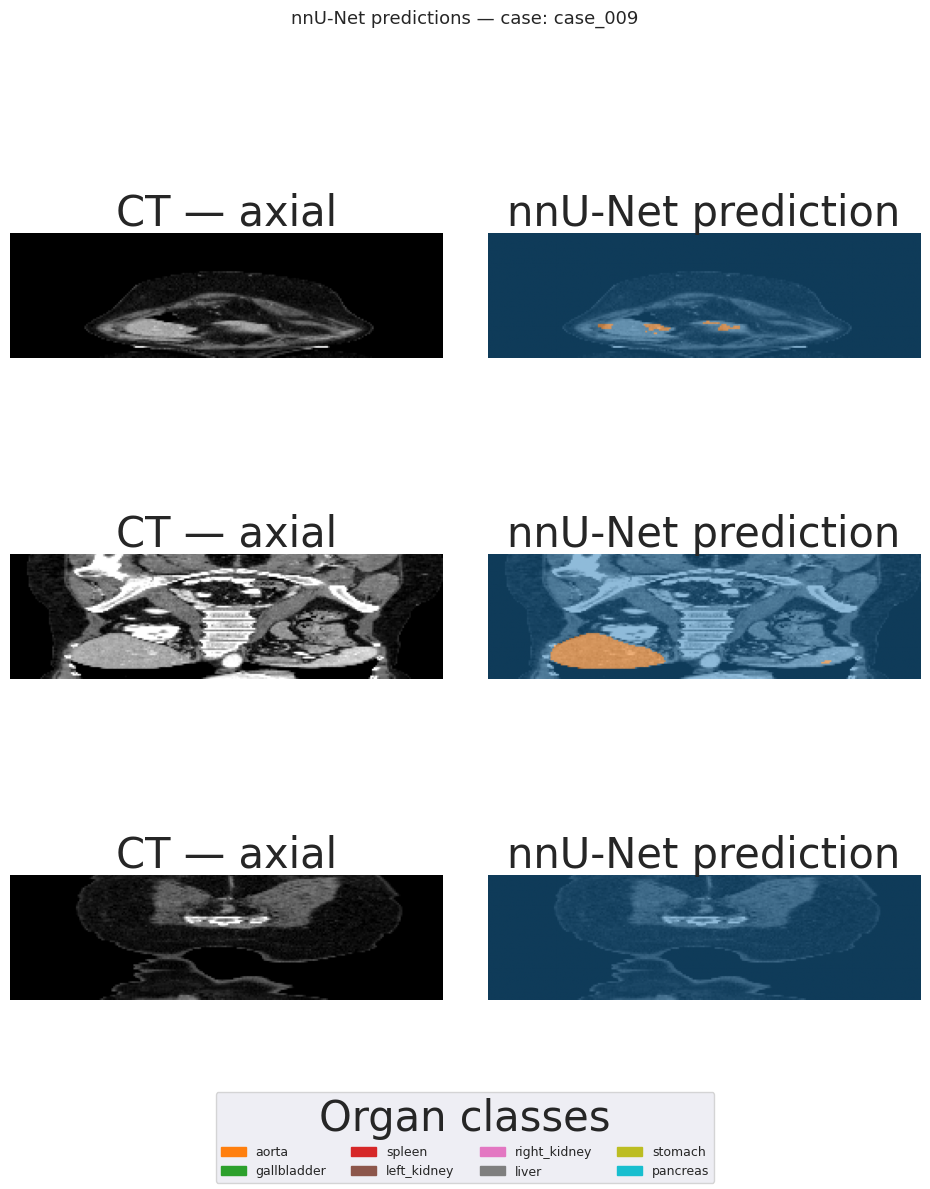

In [11]:
%matplotlib inline
from pathlib import Path
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

bridge = results['bridge']
pred_dir = Path(bridge.output_folder_base) / 'predictions_test'
pred_files = sorted(pred_dir.glob('*.nii.gz')) if pred_dir.exists() else []

if not pred_files:
    print(
        "No predictions found.\n"
        "Make sure a 'test' split was assigned before training and that training completed.\n"
        f"Expected prediction dir: {pred_dir}"
    )
else:
    # Locate the exported test images so we can display CT + prediction side-by-side.
    # The exporter writes them to: nnunet_work_dir/raw/Dataset{id}_{name}/imagesTs/
    raw_dir = trainer.nnunet_work_dir / 'raw'
    dataset_dir = sorted(raw_dir.glob('Dataset*'))[0]
    imagesTs_dir = dataset_dir / 'imagesTs'

    SYNAPSE_CLASSES = {
        1: 'aorta', 2: 'gallbladder', 3: 'spleen',
        4: 'left_kidney', 5: 'right_kidney', 6: 'liver',
        7: 'stomach', 8: 'pancreas',
    }
    num_classes = len(SYNAPSE_CLASSES)
    CMAP = plt.get_cmap('tab10', num_classes + 1)

    for pred_path in pred_files[:1]:  # show at most 2 cases to keep the notebook manageable
        case_id = pred_path.name.replace('.nii.gz', '')
        # Test images are stored as {case_id}_0000.nii.gz (channel-0 suffix added by exporter)
        img_path = imagesTs_dir / f'{case_id}_0000.nii.gz'

        pred_nii = nib.load(str(pred_path))
        pred_vol = pred_nii.get_fdata().astype(np.int32)

        if img_path.exists():
            ct_vol = nib.load(str(img_path)).get_fdata()
        else:
            ct_vol = np.zeros_like(pred_vol, dtype=np.float32)

        # nnU-Net uses (H, W, D) orientation; pick 3 evenly-spaced axial slices
        D = pred_vol.shape[2]
        slice_indices = [D // 4, D // 2, 3 * D // 4]

        fig, axes = plt.subplots(len(slice_indices), 2, figsize=(10, 4 * len(slice_indices)))
        fig.suptitle(f'nnU-Net predictions — case: {case_id}', fontsize=13)

        for row, s in enumerate(slice_indices):
            ct_slice   = ct_vol[:, :, s]
            pred_slice = pred_vol[:, :, s]

            axes[row, 0].imshow(ct_slice, cmap='gray')
            axes[row, 0].set_title(f'CT — axial')
            axes[row, 0].axis('off')

            axes[row, 1].imshow(ct_slice, cmap='gray')
            axes[row, 1].imshow(pred_slice, cmap=CMAP, alpha=0.5, vmin=0, vmax=num_classes)
            axes[row, 1].set_title(f'nnU-Net prediction')
            axes[row, 1].axis('off')

        handles = [plt.Rectangle((0, 0), 1, 1, color=CMAP(i + 1)) for i in range(num_classes)]
        labels  = list(SYNAPSE_CLASSES.values())
        fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=9, title='Organ classes')
        plt.tight_layout()
        plt.show()

## 7. Deployment
The trainer automatically registered a deployment-ready model in MLflow after training. You can deploy it directly to the Datamint server:

In [13]:
job = api.deploy.start(
    model_name=PROJECT_NAME,
    model_alias="latest",
    with_gpu=True,
)

print(f"Deployment job started!")
print(f"Job ID: {job.id}")
print(f"Status: {job.status}")

Deployment job started!
Job ID: 7daff4f4-caf9-40bd-9584-e417b6600c0f
Status: running


In [18]:
job = api.deploy.get_by_id(job.id)

print(f"Job Status: {job.status}")
print(f"Progress:   {job.progress_percentage}%")

if job.error_message:
    print(f"Error: {job.error_message}")

Job Status: completed
Progress:   100%


## 7.1 Remote Inference

In [ ]:
r = api.resources.get_list(project_name=PROJECT_NAME, limit=1)[0]

inf_job = api.inference.submit(
    model_name=PROJECT_NAME,
    model_alias="latest",
    resource_id=r.id,
)
inf_job.wait()

## 7.2 Visualise Inference Result

After the inference job completes, the predicted segmentation is uploaded back to the resource as an annotation. The cell below fetches the CT and the predicted segmentation and displays them side by side on three axial slices.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Fetch CT volume
ct_nifti = r.fetch_file_data(use_cache=True, auto_convert=True)
ct_vol = ct_nifti.get_fdata()

# Fetch the predicted segmentation (most recent annotation on this resource)
annotations = list(r.get_annotations())
pred_ann = annotations[-1]
pred_vol = pred_ann.fetch_file_data(auto_convert=True, use_cache=True)

SYNAPSE_CLASSES = {
    1: 'aorta', 2: 'gallbladder', 3: 'spleen',
    4: 'left_kidney', 5: 'right_kidney', 6: 'liver',
    7: 'stomach', 8: 'pancreas',
}
num_classes = len(SYNAPSE_CLASSES)
CMAP = plt.get_cmap('tab10', num_classes + 1)

# nnU-Net volumes are (H, W, D) — pick 3 axial slices
D = ct_vol.shape[2]
slice_indices = [D // 4, D // 2, 3 * D // 4]

fig, axes = plt.subplots(len(slice_indices), 2, figsize=(10, 4 * len(slice_indices)))
fig.suptitle(f'nnU-Net inference result — {r.filename}', fontsize=13)

for row, s in enumerate(slice_indices):
    ct_slice   = ct_vol[:, :, s]
    pred_slice = pred_vol[:, :, s]

    axes[row, 0].imshow(ct_slice, cmap='gray')
    axes[row, 0].set_title(f'CT — axial slice {s}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(ct_slice, cmap='gray')
    axes[row, 1].imshow(pred_slice, cmap=CMAP, alpha=0.5, vmin=0, vmax=num_classes)
    axes[row, 1].set_title('nnU-Net Prediction')
    axes[row, 1].axis('off')

handles = [plt.Rectangle((0, 0), 1, 1, color=CMAP(i + 1)) for i in range(num_classes)]
fig.legend(handles, list(SYNAPSE_CLASSES.values()), loc='lower center', ncol=4, fontsize=9, title='Organ classes')
plt.tight_layout()
plt.show()